In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install face_recognition
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=80a320693aca9962274afa763e93c0b51b1d283bb46f282cf06b87b805638c7d
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.datasets import fetch_olivetti_faces

In [4]:
faces = fetch_olivetti_faces()

images = faces.images
labels = faces.target

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [5]:
print(images.shape)
print(labels.shape)

(400, 64, 64)
(400,)


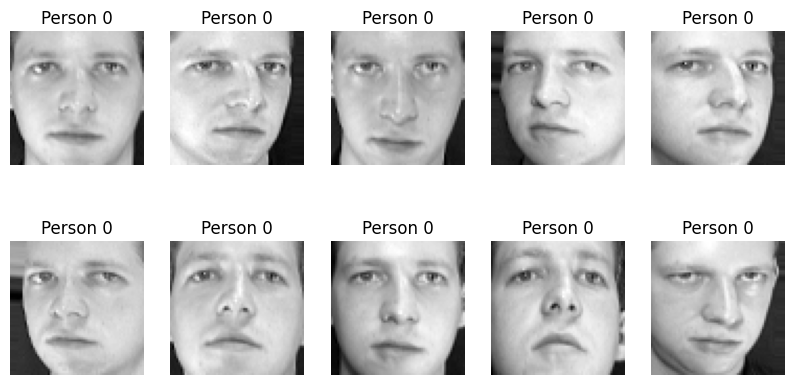

In [6]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title("Person "+str(labels[i]))
    plt.axis("off")

plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.25,
    random_state=42
)

In [8]:
X_train = X_train.reshape(len(X_train), -1)
X_test = X_test.reshape(len(X_test), -1)

In [9]:
from sklearn.svm import SVC

model = SVC(kernel="linear", probability=True)

model.fit(X_train, y_train)

SVC(kernel='linear', probability=True)

In [10]:
accuracy = model.score(X_test, y_test)

print("Accuracy:", accuracy)

Accuracy: 0.97


In [11]:
prediction = model.predict(X_test[:1])

print("Actual Person:", y_test[0])
print("Predicted Person:", prediction[0])

Actual Person: 20
Predicted Person: 20


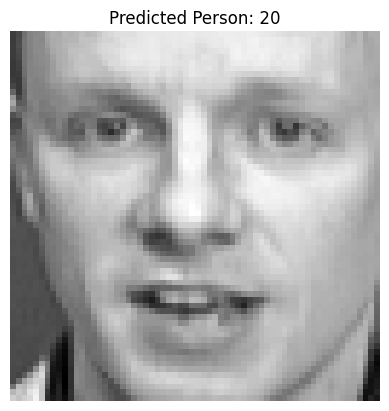

In [12]:
plt.imshow(X_test[0].reshape(64,64), cmap="gray")

plt.title("Predicted Person: "+str(prediction[0]))
plt.axis("off")
plt.show()

In [13]:
pickle.dump(
    model,
    open("/content/drive/MyDrive/SmartRetailAI/models/face_recognition.pkl","wb")
)

In [14]:
model = pickle.load(
    open("/content/drive/MyDrive/SmartRetailAI/models/face_recognition.pkl","rb")
)

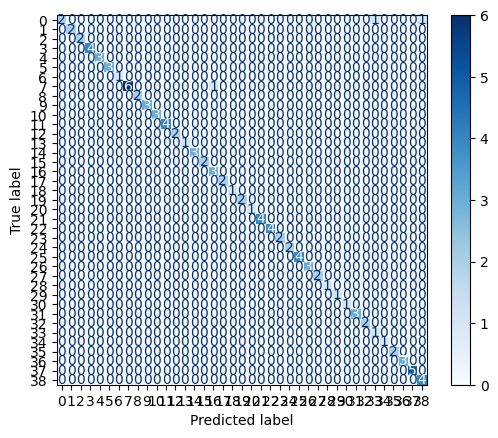

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred = model.predict(X_test)

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.savefig("/content/drive/MyDrive/SmartRetailAI/outputs/face_confusion_matrix.png")

plt.show()